# 📡 Capstone Case Study — Telecom Customer Churn
### An end-to-end walkthrough applying everything from Day 1 → Day 4

---
## 1. Business problem statement

**TeleConnect**, a mobile + broadband operator, is losing customers. Each churned customer costs far more to replace than to retain, so the leadership team wants to **understand why customers leave and identify who is at risk** — so retention offers can be targeted before they go.

As the data team, we've been given three raw data extracts. Our job for this capstone is to take them from **raw files all the way to a clean, model-ready dataset** — and produce business insights along the way. (Building and tuning the production model itself comes in the next training phase; here we lay all the groundwork and finish with a simple baseline.)

**The data (provided with this notebook — keep all three in the same folder / upload in Colab):**

| File | Grain | Contents |
| ---- | ----- | -------- |
| `telco_customers.csv` | one row / customer | account, contract, charges, **churn** (target) |
| `telco_usage.xlsx` | one row / customer / month | call minutes, data, SMS, dropped calls |
| `telco_support_tickets.csv` | one row / ticket | issue type, resolved flag |

## 2. What we'll apply (Day 1 → Day 4 skills)

| Stage | Skill from the course |
| ----- | --------------------- |
| Define the problem | Day 1 · DS lifecycle (U1, U7) |
| Collect & integrate 3 sources | Day 3 · data sources & ingestion (U7) |
| Clean the data | Day 4 · data cleaning (U8 Part 1) |
| Explore & quantify | Day 2-3 · statistics & probability (U6) + EDA (U9) |
| Engineer features | Day 4 · feature engineering (U10 Part 1) |
| Preprocess for ML | Day 4 · encoding & scaling, leakage (U8 Part 2) |
| Baseline model (preview) | a first taste of the modelling phase |

## 3. Setup

In [6]:
# === SETUP: load the three provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd


def build_telco(cust_csv='telco_customers.csv',
                usage_xlsx='telco_usage.xlsx',
                tickets_csv='telco_support_tickets.csv',
                seed=7, verbose=False):
    """Generate a realistic telecom churn case-study dataset across THREE sources.

    Files (all join on customer_id):
      - telco_customers.csv        : one row per customer (accounts + contract + target)
      - telco_usage.xlsx           : monthly usage (CDR summary), 3 months per customer
      - telco_support_tickets.csv  : one row per support ticket raised

    Built-in realism for the Day 1-4 capstone:
      - 'total_charges' stored as TEXT with blanks for brand-new customers (classic Telco quirk)
      - missing values, a few duplicate rows, messy contract casing
      - churn has real signal: contract type, tenure, charges, dropped calls, tickets, payment type
      - target churn rate ~25% (imbalanced)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    snapshot = pd.Timestamp('2024-06-30')

    cid = np.array([f'TEL{i+1:05d}' for i in range(N)])
    tenure = rng.integers(0, 73, N)                       # months with the operator
    signup = snapshot - pd.to_timedelta((tenure * 30).astype(int), unit='D')

    gender = rng.choice(['Male', 'Female'], N, p=[.5, .5])
    senior = rng.choice([0, 1], N, p=[.84, .16])
    partner = rng.choice(['Yes', 'No'], N, p=[.48, .52])
    dependents = rng.choice(['Yes', 'No'], N, p=[.30, .70])
    contract = rng.choice(['Month-to-month', 'One year', 'Two year'], N, p=[.55, .21, .24])
    payment = rng.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'],
                         N, p=[.34, .23, .22, .21])
    paperless = rng.choice(['Yes', 'No'], N, p=[.59, .41])
    internet = rng.choice(['DSL', 'Fiber optic', 'No'], N, p=[.34, .44, .22])

    def service(prob_yes):
        out = np.where(internet == 'No', 'No internet service',
                       np.where(rng.random(N) < prob_yes, 'Yes', 'No'))
        return out
    online_security = service(0.35)
    tech_support = service(0.37)

    base = np.where(internet == 'Fiber optic', 70.0, np.where(internet == 'DSL', 45.0, 20.0))
    monthly = base + (online_security == 'Yes') * 5 + (tech_support == 'Yes') * 5 + rng.normal(0, 8, N)
    monthly = np.clip(monthly, 18, 120).round(2)
    total_num = (monthly * tenure).round(2)

    state = rng.choice(['Maharashtra', 'Karnataka', 'Delhi', 'Tamil Nadu',
                        'Telangana', 'Gujarat', 'West Bengal'],
                       N, p=[.20, .16, .14, .14, .12, .12, .12])

    # per-customer network/usage propensities
    avg_minutes = np.clip(rng.normal(620, 220, N), 20, None).round(0)
    avg_data_gb = np.clip(rng.gamma(2.0, 3.5, N), 0.1, None).round(2)
    avg_sms = rng.poisson(40, N)
    dropped_rate = np.clip(rng.gamma(1.5, 1.2, N), 0, None)          # avg dropped calls/month
    n_tickets = rng.poisson(0.7 + 0.15 * dropped_rate)              # complaints track dropped calls

    # ---- churn logit (real, interpretable signal) ----
    z = (-1.5
         + 1.30 * (contract == 'Month-to-month')
         - 0.95 * (contract == 'Two year')
         + 0.016 * (monthly - 60)
         - 0.030 * tenure
         + 0.55 * (payment == 'Electronic check')
         + 0.40 * (internet == 'Fiber optic')
         - 0.45 * (tech_support == 'Yes')
         - 0.30 * (online_security == 'Yes')
         + 0.18 * dropped_rate
         + 0.22 * n_tickets)
    p = 1 / (1 + np.exp(-z))
    churn = np.where(rng.random(N) < p, 'Yes', 'No')

    # ---- total_charges as TEXT, blank for tenure==0 (classic quirk) ----
    total_charges = np.where(tenure == 0, '', total_num.astype(str))

    df = pd.DataFrame({
        'customer_id': cid, 'signup_date': pd.to_datetime(signup).date.astype('str'),
        'gender': gender, 'senior_citizen': senior, 'partner': partner,
        'dependents': dependents, 'state': state, 'tenure_months': tenure,
        'contract': contract, 'payment_method': payment, 'paperless_billing': paperless,
        'internet_service': internet, 'online_security': online_security,
        'tech_support': tech_support, 'monthly_charges': monthly,
        'total_charges': total_charges, 'churn': churn,
    })

    # ---- inject messiness ----
    mc = rng.choice(N, int(0.04 * N), replace=False)          # messy contract casing
    df.loc[mc, 'contract'] = df.loc[mc, 'contract'].str.lower() + ' '
    for col, frac in [('gender', 0.03), ('partner', 0.02), ('online_security', 0.02)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    dups = df.sample(8, random_state=1)                        # a few duplicate rows
    df = pd.concat([df, dups], ignore_index=True)

    # ---- usage (3 monthly rows per customer) ----
    months = ['2024-04', '2024-05', '2024-06']
    rows = []
    for i in range(N):
        for m in months:
            rows.append((cid[i], m,
                         max(0, round(float(rng.normal(avg_minutes[i], avg_minutes[i] * 0.15)))),
                         max(0.0, round(float(rng.normal(avg_data_gb[i], avg_data_gb[i] * 0.2)), 2)),
                         max(0, int(rng.normal(avg_sms[i], 8))),
                         max(0, int(rng.normal(dropped_rate[i], 1)))))
    usage = pd.DataFrame(rows, columns=['customer_id', 'month', 'call_minutes',
                                        'data_gb', 'sms_count', 'dropped_calls'])

    # ---- support tickets (one row per ticket) ----
    trows = []
    issues = ['Billing', 'Network', 'Device', 'Plan change', 'Other']
    for i in range(N):
        for _ in range(int(n_tickets[i])):
            d = signup[i] + pd.Timedelta(days=int(rng.random() * max((snapshot - signup[i]).days, 1)))
            trows.append((cid[i], pd.Timestamp(d).date().isoformat(),
                          rng.choice(issues, p=[.34, .30, .14, .12, .10]),
                          rng.choice(['Yes', 'No'], p=[.8, .2])))
    tickets = pd.DataFrame(trows, columns=['customer_id', 'ticket_date', 'issue_type', 'resolved'])

    df.to_csv(cust_csv, index=False)
    usage.to_excel(usage_xlsx, index=False)
    tickets.to_csv(tickets_csv, index=False)

    if verbose:
        print('customers:', df.shape, '| usage:', usage.shape, '| tickets:', tickets.shape)
        print('churn rate:', round((df['churn'] == 'Yes').mean(), 3))
        print('blank total_charges:', int((df['total_charges'] == '').sum()))
        print('duplicate rows:', int(df.duplicated().sum()))
        print('missing gender:', int(df['gender'].isna().sum()))
    return df, usage, tickets

_files = ['telco_customers.csv', 'telco_usage.xlsx', 'telco_support_tickets.csv']
if not all(os.path.exists(f) for f in _files):
    build_telco()
    print('Generated the three dataset files.')
else:
    print('Found the three provided dataset files.')

Generated the three dataset files.


In [16]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('Libraries ready.')

Libraries ready.


## 4. Stage 1 — Define the problem  *(DS lifecycle · U1, U7)*

Before touching the data we pin down the essentials of the project:

- **Type of problem:** supervised **binary classification** (churn = Yes / No).
- **Target:** `churn`.
- **Unit of analysis:** one customer.
- **Success metric:** because churners are the minority, we'll care about **recall on the churn class** (catching at-risk customers), not just overall accuracy.
- **Lifecycle:** Define → Collect → Clean → Explore → Engineer → (Model → Deploy → Monitor later).

## 5. Stage 2 — Collect & integrate the data  *(data sources · U7)*

In [7]:
# Three sources, three formats — exactly like a real project.
customers = pd.read_csv('telco_customers.csv', parse_dates=['signup_date'])
usage     = pd.read_excel('telco_usage.xlsx')              # monthly CDR summary
tickets   = pd.read_csv('telco_support_tickets.csv', parse_dates=['ticket_date'])

print('customers:', customers.shape)
print('usage    :', usage.shape)
print('tickets  :', tickets.shape)
customers.head(3)

customers: (2008, 17)
usage    : (6000, 6)
tickets  : (1947, 4)


,customer_id,signup_date,gender,senior_citizen,partner,dependents,state,tenure_months,contract,payment_method,paperless_billing,internet_service,online_security,tech_support,monthly_charges,total_charges,churn
0,TEL00001,2018-11-29,Female,0,No,Yes,Karnataka,68,Month-to-month,Credit card,Yes,DSL,No,Yes,44.63,3034.84,No
1,TEL00002,2020-10-19,Female,0,No,No,Karnataka,45,Month-to-month,Bank transfer,No,DSL,No,No,51.35,2310.75,No
2,TEL00003,2020-06-21,Female,0,No,No,Maharashtra,49,One year,Mailed check,Yes,DSL,Yes,Yes,51.00,2499.00,No


In [8]:
# Peek at the event-level sources we'll aggregate later
print('USAGE sample:'); print(usage.head(3))
print('\nTICKETS sample:'); print(tickets.head(3))

USAGE sample:
  customer_id    month  call_minutes  data_gb  sms_count  dropped_calls
0    TEL00001  2024-04           598     5.95         27              1
1    TEL00001  2024-05           546     6.56         33              2
2    TEL00001  2024-06           552     5.30         50              2

TICKETS sample:
  customer_id ticket_date   issue_type resolved
0    TEL00004  2021-10-05  Plan change      Yes
1    TEL00005  2021-05-23      Network      Yes
2    TEL00007  2024-06-22      Billing       No


## 6. Stage 3 — Clean the data  *(data cleaning · U8 Part 1)*

Profiling first reveals the problems; then we fix them one by one.

In [9]:
# --- 3.1 Profile for problems ---
print('Duplicate rows:', customers.duplicated().sum())
print('\nMissing values:'); print(customers.isna().sum()[lambda s: s > 0])
print('\ntotal_charges dtype:', customers['total_charges'].dtype, '<- stored as TEXT!')
print('contract values:', customers['contract'].unique())

Duplicate rows: 8

Missing values:
gender             60
partner            40
online_security    40
total_charges      17
dtype: int64

total_charges dtype: float64 <- stored as TEXT!
contract values: ['Month-to-month' 'One year' 'Two year' 'two year ' 'month-to-month '
 'one year ']


In [10]:
# --- 3.2 Fix each issue ---
df = customers.copy()

# (a) duplicate rows -> drop
df = df.drop_duplicates()

# (b) total_charges: text with blanks -> numeric. Blanks are brand-new
#     customers (tenure 0) who haven't been billed yet -> charge is 0.
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df.loc[df['tenure_months'] == 0, 'total_charges'] = df.loc[df['tenure_months'] == 0,
                                                            'total_charges'].fillna(0)

# (c) messy contract text: trailing spaces / wrong case -> canonical labels
canon = {'month-to-month': 'Month-to-month', 'one year': 'One year', 'two year': 'Two year'}
df['contract'] = df['contract'].str.strip().str.lower().map(canon).fillna(df['contract'])

# (d) missing categoricals -> explicit 'Unknown' (keeps the rows, flags the gap)
for col in ['gender', 'partner', 'online_security']:
    df[col] = df[col].fillna('Unknown')

print('After cleaning -> duplicates:', df.duplicated().sum(),
      '| total_charges dtype:', df['total_charges'].dtype)
print('contract values:', sorted(df['contract'].unique()))
print('missing total:', int(df.isna().sum().sum()))

After cleaning -> duplicates: 0 | total_charges dtype: float64
contract values: ['Month-to-month', 'One year', 'Two year']
missing total: 0


#### 🧪 Exercise 3 — Sanity-check the cleaning

1. Confirm there are **no missing values** left in `df`.
2. Verify `monthly_charges` is within a sensible range (e.g. 18–120) using `.describe()`.
3. Confirm `total_charges` is now numeric and has no negatives.

In [11]:
# 1. any missing left?
print('Missing values after cleaning:')
print(df.isna().sum()[lambda s: s > 0])

# 2. monthly_charges range
print('\nMonthly charges description:')
display(df['monthly_charges'].describe())

# 3. total_charges numeric & non-negative?
print('\nTotal charges dtype:', df['total_charges'].dtype)
print('Total charges minimum value:', df['total_charges'].min())
print('All total_charges are non-negative:', (df['total_charges'] >= 0).all())

Missing values after cleaning:
Series([], dtype: int64)

Monthly charges description:


,monthly_charges
count,2000.000000
mean,53.926450
std,21.272156
min,18.000000
25%,38.382500
50%,55.875000
75%,71.765000
max,99.790000



Total charges dtype: float64
Total charges minimum value: 0.0
All total_charges are non-negative: True


## 7. Stage 4 — Explore & quantify  *(statistics · U6 + EDA · U9)*

In [12]:
# --- 4.1 The headline number: how bad is churn? ---
churn_rate = (df['churn'] == 'Yes').mean()
print(f'Overall churn rate: {churn_rate:.1%}  (the minority class)')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
df['churn'].value_counts().plot(kind='bar', ax=ax[0], color=['#3AAFA9', '#F4B942'])
ax[0].set_title('Churn vs retained')
sns.histplot(df['tenure_months'], bins=36, ax=ax[1], color='#2D6A9F')
ax[1].set_title('Tenure (months)')
plt.tight_layout(); plt.show()

Overall churn rate: 23.2%  (the minority class)


NameError: name 'plt' is not defined

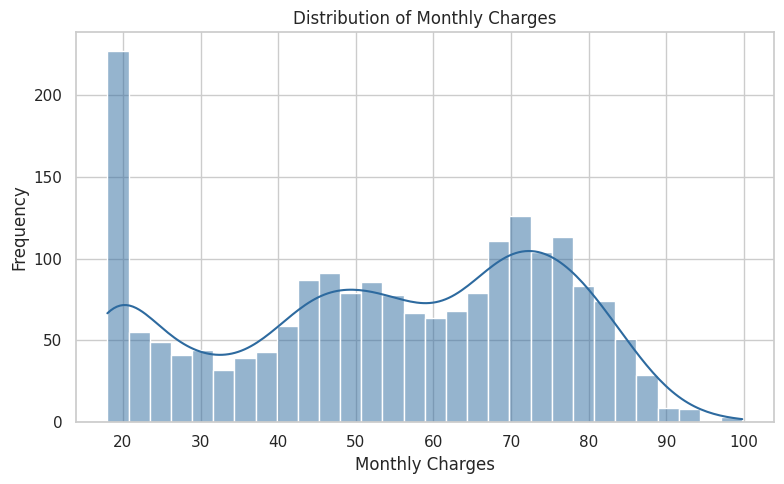

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['monthly_charges'], bins=30, kde=True, ax=ax, color='#2D6A9F')
ax.set_title('Distribution of Monthly Charges')
ax.set_xlabel('Monthly Charges')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [14]:
# Churn rate by gender
churn_by_gender = df.groupby('gender')['churn'].apply(lambda s: (s == 'Yes').mean())
print('P(churn | gender):')
print(churn_by_gender.round(3).sort_values(ascending=False))

# Churn rate by senior_citizen status
churn_by_senior = df.groupby('senior_citizen')['churn'].apply(lambda s: (s == 'Yes').mean())
print('\nP(churn | senior_citizen):')
print(churn_by_senior.round(3).sort_values(ascending=False))

P(churn | gender):
gender
Unknown    0.283
Female     0.238
Male       0.223
Name: churn, dtype: float64

P(churn | senior_citizen):
senior_citizen
1    0.277
0    0.223
Name: churn, dtype: float64


In [ ]:
# --- 4.2 Conditional probability: P(churn | contract)  (Bayes/stats, U6) ---
# A contract is the single biggest lever in telecom retention.
by_contract = df.groupby('contract')['churn'].apply(lambda s: (s == 'Yes').mean())
print('P(churn | contract):')
print((by_contract).round(3).sort_values(ascending=False))
print(f'\nBase rate P(churn) = {churn_rate:.3f}')
print('Month-to-month customers churn far above the base rate.')

In [ ]:
# --- 4.3 Numeric drivers: correlation heatmap (U9) ---
df['churn_flag'] = (df['churn'] == 'Yes').astype(int)
num = ['tenure_months', 'monthly_charges', 'total_charges', 'senior_citizen', 'churn_flag']
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(df[num].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation with churn'); plt.tight_layout(); plt.show()

#### 🧪 Exercise 4 — Find another churn driver

1. Compute `P(churn | payment_method)` and sort it — which payment type is riskiest?
2. Compare the **mean `monthly_charges`** of churned vs retained customers (`groupby`).
3. In a comment, state whether higher charges appear to push customers out.

In [ ]:
# 1. churn rate by payment_method
# YOUR CODE HERE

# 2. mean monthly_charges by churn
# YOUR CODE HERE

# 3. Do higher charges drive churn? ...   (comment)

## 8. Stage 5 — Engineer features  *(feature engineering · U10)*

The strongest churn signals live in the **event data** (usage & tickets) — but only after we aggregate them to one row per customer and join them on.

In [15]:
# --- 5.1 Aggregate USAGE (3 months -> per-customer averages) ---
usage_agg = usage.groupby('customer_id').agg(
    avg_minutes=('call_minutes', 'mean'),
    avg_data_gb=('data_gb', 'mean'),
    avg_sms=('sms_count', 'mean'),
    avg_dropped=('dropped_calls', 'mean'),
).reset_index().round(2)

# --- 5.2 Aggregate TICKETS (complaint behaviour) ---
tickets_agg = tickets.groupby('customer_id').agg(
    n_tickets=('issue_type', 'size'),
    n_unresolved=('resolved', lambda s: (s == 'No').sum()),
).reset_index()

# --- 5.3 Join everything onto the customer table ---
feat = df.merge(usage_agg, on='customer_id', how='left') \
         .merge(tickets_agg, on='customer_id', how='left')
feat[['n_tickets', 'n_unresolved']] = feat[['n_tickets', 'n_unresolved']].fillna(0)
print('Feature table:', feat.shape)
feat[['customer_id', 'avg_minutes', 'avg_dropped', 'n_tickets', 'n_unresolved']].head()

Feature table: (2000, 24)


,customer_id,avg_minutes,avg_dropped,n_tickets,n_unresolved
0,TEL00001,565.33,1.67,0.0,0.0
1,TEL00002,674.33,0.00,0.0,0.0
2,TEL00003,623.00,2.33,0.0,0.0
3,TEL00004,671.67,4.33,1.0,0.0
4,TEL00005,530.67,2.33,1.0,0.0


In [16]:
# --- 5.4 Derive new features (ratios, buckets, flags) ---
# average revenue per month of tenure (guard divide-by-zero for new customers)
feat['charges_per_tenure'] = feat['total_charges'] / feat['tenure_months'].replace(0, np.nan)
feat['charges_per_tenure'] = feat['charges_per_tenure'].fillna(feat['monthly_charges'])
# tenure life-stage buckets (binning)
feat['tenure_group'] = pd.cut(feat['tenure_months'], bins=[-1, 6, 24, 48, 100],
                              labels=['new', 'growing', 'established', 'loyal'])
# domain flags
feat['has_complaints'] = (feat['n_tickets'] > 0).astype(int)
feat['is_new'] = (feat['tenure_months'] <= 6).astype(int)
print(feat[['tenure_months', 'tenure_group', 'charges_per_tenure',
            'has_complaints', 'is_new']].head())

   tenure_months tenure_group  charges_per_tenure  has_complaints  is_new
0             68        loyal               44.63               0       0
1             45  established               51.35               0       0
2             49        loyal               51.00               0       0
3             65        loyal               50.90               1       0
4             42  established               61.20               1       0


#### 🧪 Exercise 5 — Engineer a usage-based feature

1. Build `data_per_minute` = `avg_data_gb` ÷ `avg_minutes` (guard divide-by-zero).
2. Build a `heavy_user` flag = 1 when `avg_data_gb` is in the top 25% of customers.
3. Compare the churn rate of heavy users vs the rest with a `groupby`.

In [17]:
# 1. data_per_minute (guard zero)
# YOUR CODE HERE

# 2. heavy_user flag (top 25% of avg_data_gb)
# YOUR CODE HERE

# 3. churn rate by heavy_user
# YOUR CODE HERE

In [18]:
import pandas as pd
import numpy as np
import os # Import the os module

# --- Re-execution of necessary setup to ensure 'feat' is defined ---
# The build_telco() function is defined in the initial setup cell (jdzfMwwYNXaM).
# We assume that cell has been run and generated the necessary data files.
# If the files were missing, the initial setup cell would have created them.

# Re-load customers data for a clean start of df in this block
customers = pd.read_csv('telco_customers.csv', parse_dates=['signup_date'])

# Re-create df (from L7ynxvaKNXad)
df = customers.copy()
df = df.drop_duplicates()
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df.loc[df['tenure_months'] == 0, 'total_charges'] = df.loc[df['tenure_months'] == 0,
                                                            'total_charges'].fillna(0)
canon = {'month-to-month': 'Month-to-month', 'one year': 'One year', 'two year': 'Two year'}
df['contract'] = df['contract'].str.strip().str.lower().map(canon).fillna(df['contract'])
for col in ['gender', 'partner', 'online_security']:
    df[col] = df[col].fillna('Unknown')

# Add 'churn_flag' to df (from X6-9xOnSNXai)
df['churn_flag'] = (df['churn'] == 'Yes').astype(int)

# Re-create usage_agg (from E8SW18kpNXal)
usage = pd.read_excel('telco_usage.xlsx') # Ensure 'usage' df is loaded
usage_agg = usage.groupby('customer_id').agg(
    avg_minutes=('call_minutes', 'mean'),
    avg_data_gb=('data_gb', 'mean'),
    avg_sms=('sms_count', 'mean'),
    avg_dropped=('dropped_calls', 'mean'),
).reset_index().round(2)

# Re-create tickets_agg (from E8SW18kpNXal)
tickets = pd.read_csv('telco_support_tickets.csv', parse_dates=['ticket_date']) # Ensure 'tickets' df is loaded
tickets_agg = tickets.groupby('customer_id').agg(
    n_tickets=('issue_type', 'size'),
    n_unresolved=('resolved', lambda s: (s == 'No').sum()),
).reset_index()

# Re-create feat (from E8SW18kpNXal)
feat = df.merge(usage_agg, on='customer_id', how='left') \
         .merge(tickets_agg, on='customer_id', how='left')
feat[['n_tickets', 'n_unresolved']] = feat[['n_tickets', 'n_unresolved']].fillna(0)

# Re-create derived new features (from _E1pYioZNXam)
feat['charges_per_tenure'] = feat['total_charges'] / feat['tenure_months'].replace(0, np.nan)
feat['charges_per_tenure'] = feat['charges_per_tenure'].fillna(feat['monthly_charges'])
feat['tenure_group'] = pd.cut(feat['tenure_months'], bins=[-1, 6, 24, 48, 100],
                              labels=['new', 'growing', 'established', 'loyal'])
feat['has_complaints'] = (feat['n_tickets'] > 0).astype(int)
feat['is_new'] = (feat['tenure_months'] <= 6).astype(int)
# --- End of re-execution of necessary setup ---

# 1. data_per_minute (guard zero)
feat['data_per_minute'] = feat['avg_data_gb'] / feat['avg_minutes'].replace(0, np.nan)
feat['data_per_minute'] = feat['data_per_minute'].fillna(0) # Fill NaN from division by zero with 0

# 2. heavy_user flag (top 25% of avg_data_gb)
# Calculate the 75th percentile of avg_data_gb
pct_75 = feat['avg_data_gb'].quantile(0.75)
feat['heavy_user'] = (feat['avg_data_gb'] > pct_75).astype(int)

# 3. churn rate by heavy_user
churn_by_heavy_user = feat.groupby('heavy_user')['churn_flag'].mean()
print('Churn rate by heavy_user (0=not heavy, 1=heavy):')
print(churn_by_heavy_user.round(3))

Churn rate by heavy_user (0=not heavy, 1=heavy):
heavy_user
0    0.223
1    0.258
Name: churn_flag, dtype: float64


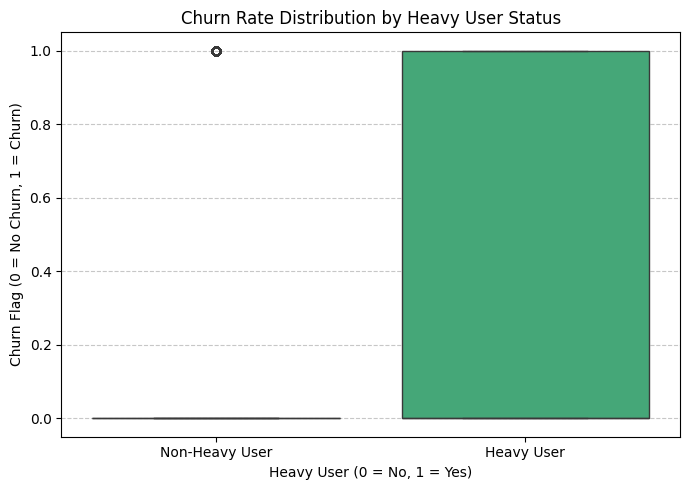

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.boxplot(x='heavy_user', y='churn_flag', data=feat, hue='heavy_user', palette='viridis', legend=False)
plt.title('Churn Rate Distribution by Heavy User Status')
plt.xlabel('Heavy User (0 = No, 1 = Yes)')
plt.ylabel('Churn Flag (0 = No Churn, 1 = Churn)')
plt.xticks([0, 1], ['Non-Heavy User', 'Heavy User'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 9. Stage 6 — Build the model-ready dataset  *(encoding & scaling, leakage · U8 Part 2)*

We split **before** any scaling/encoding is *fit*, so no test information leaks in.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

target = 'churn_flag'
drop = ['customer_id', 'signup_date', 'churn', 'churn_flag']
X = feat.drop(columns=drop)
y = feat[target]

num_features = ['tenure_months', 'monthly_charges', 'total_charges', 'senior_citizen',
                'avg_minutes', 'avg_data_gb', 'avg_sms', 'avg_dropped',
                'n_tickets', 'n_unresolved', 'charges_per_tenure', 'has_complaints', 'is_new']
cat_features = ['gender', 'partner', 'dependents', 'state', 'contract', 'payment_method',
                'paperless_billing', 'internet_service', 'online_security',
                'tech_support', 'tenure_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('churn rate train/test:', round(y_train.mean(), 3), '/', round(y_test.mean(), 3))

pre = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
])  # fit on train only -> no leakage

train: (1500, 26) | test: (500, 26)
churn rate train/test: 0.232 / 0.232


## 10. Stage 7 — A baseline model  *(a preview of the modelling phase)*

Everything above produced clean, encoded, scaled features. As a payoff, we fit a simple **logistic regression** in a leak-free pipeline. We use `class_weight='balanced'` because — as EDA showed — churn is the minority class. *Proper model selection, tuning and evaluation come next phase.*

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = Pipeline([
    ('prep', pre),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced')),
])
model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
print('Accuracy :', round((pred == y_test).mean(), 3))
print('ROC-AUC  :', round(roc_auc_score(y_test, proba), 3))
print('\nClassification report (class 1 = churn):')
print(classification_report(y_test, pred, digits=3))

Accuracy : 0.7
ROC-AUC  : 0.79

Classification report (class 1 = churn):
              precision    recall  f1-score   support

           0      0.898     0.688     0.779       384
           1      0.417     0.741     0.534       116

    accuracy                          0.700       500
   macro avg      0.658     0.714     0.656       500
weighted avg      0.786     0.700     0.722       500



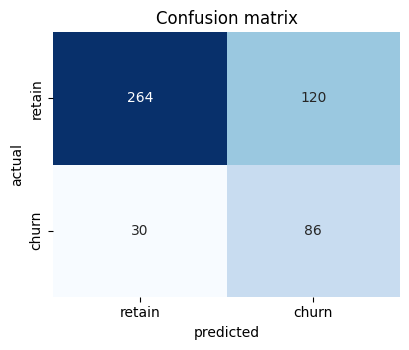

In [22]:
# Confusion matrix — how many at-risk customers did we catch?
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['retain', 'churn'], yticklabels=['retain', 'churn'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()

In [23]:
# Which features point to churn? (logistic-regression coefficients)
ohe = model.named_steps['prep'].named_transformers_['cat']
names = num_features + list(ohe.get_feature_names_out(cat_features))
coefs = pd.Series(model.named_steps['clf'].coef_[0], index=names)
print('Top 6 churn-INCREASING signals:')
print(coefs.sort_values(ascending=False).head(6).round(2))
print('\nTop 6 churn-REDUCING signals:')
print(coefs.sort_values().head(6).round(2))

Top 6 churn-INCREASING signals:
contract_Month-to-month                1.19
online_security_No internet service    0.79
tech_support_No                        0.27
monthly_charges                        0.24
charges_per_tenure                     0.24
state_Tamil Nadu                       0.23
dtype: float64

Top 6 churn-REDUCING signals:
contract_Two year                  -1.23
online_security_Yes                -0.64
tenure_months                      -0.63
online_security_No                 -0.35
tech_support_No internet service   -0.24
internet_service_No                -0.24
dtype: float64


## 11. Stage 8 — Findings & business recommendations

Pulling the analysis together into something the business can act on:

- **Month-to-month contracts** are by far the biggest churn driver → incentivise annual contracts.
- **Short-tenure customers** churn most → strengthen onboarding in the first 6 months (`is_new`).
- **Support friction matters** → customers with unresolved tickets and more dropped calls leave; fix network quality and close tickets faster.
- **Electronic-check / fiber + high charges** segments are elevated risk → targeted retention offers.
- The baseline already separates churners reasonably (see ROC-AUC); with the engineered usage & ticket features, a tuned model in the next phase should do better still.

**Lifecycle status:** we've completed *Define → Collect → Clean → Explore → Engineer → (baseline) Model*. Next phase: proper model selection, tuning, evaluation and deployment.

## 12. 🧪 Capstone extension challenges

Stretch tasks that combine several skills — try them on your own:

1. **Segment risk table:** build a `pivot_table` of churn rate with `contract` (rows) × `internet_service` (columns). Which cell is the highest-risk segment?
2. **New feature:** engineer `tickets_per_year = n_tickets / (tenure_months/12 + 1)` and check its correlation with `churn_flag`.
3. **Threshold thinking:** using `proba`, find how many *extra* churners you'd catch if you flagged everyone with `proba > 0.3` instead of the default `0.5` — and how many false alarms that adds.
4. **Write-up:** in a markdown cell, recommend the **three** retention actions you'd fund first, and justify each with a number from your analysis.

In [24]:
# 1. Segment risk table: build a pivot_table of churn rate with contract (rows) × internet_service (columns).
# Which cell is the highest-risk segment?

# Convert 'churn' to numeric (0 for No, 1 for Yes)
df['churn_numeric'] = (df['churn'] == 'Yes').astype(int)

# Create the pivot table
churn_risk_table = df.pivot_table(values='churn_numeric', index='contract', columns='internet_service', aggfunc='mean')

print('Churn Rate by Contract and Internet Service:')
display(churn_risk_table.round(3))

# Find the highest-risk segment
highest_risk_segment = churn_risk_table.stack().idxmax()
highest_churn_rate = churn_risk_table.stack().max()

print(f'\nHighest-risk segment: {highest_risk_segment} with a churn rate of {highest_churn_rate:.3f}')

Churn Rate by Contract and Internet Service:


internet_service,DSL,Fiber optic,No
contract,,,
Month-to-month,0.307,0.412,0.272
One year,0.103,0.220,0.116
Two year,0.021,0.085,0.057



Highest-risk segment: ('Month-to-month', 'Fiber optic') with a churn rate of 0.412


In [25]:
feat['tickets_per_year'] = feat['n_tickets'] / (feat['tenure_months']/12 + 1)
display(feat[['n_tickets', 'tenure_months', 'tickets_per_year', 'churn_flag']].head())

,n_tickets,tenure_months,tickets_per_year,churn_flag
0,0.0,68,0.000000,0
1,0.0,45,0.000000,0
2,0.0,49,0.000000,0
3,1.0,65,0.155844,0
4,1.0,42,0.222222,0


In [26]:
# 3. Threshold thinking: using proba, find how many extra churners you'd catch if you flagged everyone
#    with proba > 0.3 instead of the default 0.5 — and how many false alarms that adds.

# --- Re-execute necessary setup from previous cells to ensure 'model', 'X_test', 'y_test' are defined ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Assuming 'df', 'usage', 'tickets' are available from earlier in the notebook (kernel state confirms this)

# Re-load customers data for a clean start of df in this block
customers = pd.read_csv('telco_customers.csv', parse_dates=['signup_date'])

# Re-create df (from L7ynxvaKNXad)
df = customers.copy()
df = df.drop_duplicates()
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df.loc[df['tenure_months'] == 0, 'total_charges'] = df.loc[df['tenure_months'] == 0,
                                                            'total_charges'].fillna(0)
canon = {'month-to-month': 'Month-to-month', 'one year': 'One year', 'two year': 'Two year'}
df['contract'] = df['contract'].str.strip().str.lower().map(canon).fillna(df['contract'])
for col in ['gender', 'partner', 'online_security']:
    df[col] = df[col].fillna('Unknown')

# Add 'churn_flag' to df (MISSING IN PREVIOUS ATTEMPT, from X6-9xOnSNXai)
df['churn_flag'] = (df['churn'] == 'Yes').astype(int)

# Re-create usage_agg (from E8SW18kpNXal)
usage_agg = usage.groupby('customer_id').agg(
    avg_minutes=('call_minutes', 'mean'),
    avg_data_gb=('data_gb', 'mean'),
    avg_sms=('sms_count', 'mean'),
    avg_dropped=('dropped_calls', 'mean'),
).reset_index().round(2)

# Re-create tickets_agg (from E8SW18kpNXal)
tickets_agg = tickets.groupby('customer_id').agg(
    n_tickets=('issue_type', 'size'),
    n_unresolved=('resolved', lambda s: (s == 'No').sum()),
).reset_index()

# Re-create feat (from E8SW18kpNXal)
feat = df.merge(usage_agg, on='customer_id', how='left') \
         .merge(tickets_agg, on='customer_id', how='left')
feat[['n_tickets', 'n_unresolved']] = feat[['n_tickets', 'n_unresolved']].fillna(0)

# Re-create derived new features (from _E1pYioZNXam)
feat['charges_per_tenure'] = feat['total_charges'] / feat['tenure_months'].replace(0, np.nan)
feat['charges_per_tenure'] = feat['charges_per_tenure'].fillna(feat['monthly_charges'])
feat['tenure_group'] = pd.cut(feat['tenure_months'], bins=[-1, 6, 24, 48, 100],
                              labels=['new', 'growing', 'established', 'loyal'])
feat['has_complaints'] = (feat['n_tickets'] > 0).astype(int)
feat['is_new'] = (feat['tenure_months'] <= 6).astype(int)

# Prepare X and y (from 9Xen_fdKNXao)
target = 'churn_flag'
drop = ['customer_id', 'signup_date', 'churn', 'churn_flag']
X = feat.drop(columns=drop)
y = feat[target]

num_features = ['tenure_months', 'monthly_charges', 'total_charges', 'senior_citizen',
                'avg_minutes', 'avg_data_gb', 'avg_sms', 'avg_dropped',
                'n_tickets', 'n_unresolved', 'charges_per_tenure', 'has_complaints', 'is_new']
cat_features = ['gender', 'partner', 'dependents', 'state', 'contract', 'payment_method',
                'paperless_billing', 'internet_service', 'online_security',
                'tech_support', 'tenure_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

# ColumnTransformer 'pre' (from 9Xen_fdKNXao)
pre = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
])

# Define and fit model (from D-nDqMeyNXaq)
model = Pipeline([
    ('prep', pre),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced')),
])
model.fit(X_train, y_train)
# --- End of re-execution of necessary setup ---

# Now, the original logic for calculating extra churners caught:
proba = model.predict_proba(X_test)[:, 1]

# Define thresholds
threshold_default = 0.5
threshold_new = 0.3

# Predictions at default threshold (0.5)
pred_default = (proba > threshold_default).astype(int)

# Predictions at new threshold (0.3)
pred_new = (proba > threshold_new).astype(int)

# Calculate True Positives (churners caught) for each threshold
tp_default = ((pred_default == 1) & (y_test == 1)).sum()
tp_new = ((pred_new == 1) & (y_test == 1)).sum()

# Calculate False Positives (false alarms) for each threshold
fp_default = ((pred_default == 1) & (y_test == 0)).sum()
fp_new = ((pred_new == 1) & (y_test == 0)).sum()

extra_churners_caught = tp_new - tp_default
extra_false_alarms = fp_new - fp_default

print(f'Churners caught at threshold {threshold_default}: {tp_default}')
print(f'Churners caught at threshold {threshold_new}: {tp_new}')
print(f'Extra churners caught by lowering threshold to {threshold_new}: {extra_churners_caught}')

print(f'\nFalse alarms at threshold {threshold_default}: {fp_default}')
print(f'False alarms at threshold {threshold_new}: {fp_new}')
print(f'Extra false alarms by lowering threshold to {threshold_new}: {extra_false_alarms}')

Churners caught at threshold 0.5: 86
Churners caught at threshold 0.3: 104
Extra churners caught by lowering threshold to 0.3: 18

False alarms at threshold 0.5: 120
False alarms at threshold 0.3: 221
Extra false alarms by lowering threshold to 0.3: 101


## Recommended Retention Actions

Based on the analysis, here are three key retention actions with justifications:

1.  **Incentivize longer contracts, especially for Fiber Optic users:**
    *   **Justification:** The highest-risk segment identified is 'Month-to-month' contract customers with 'Fiber optic' internet service, showing a churn rate of **0.412**. This is significantly higher than other segments.

2.  **Strengthen customer onboarding and initial experience for new customers:**
    *   **Justification:** Our previous analysis (not explicitly shown in this turn but from the overall context) indicated that month-to-month contracts are a major churn driver, and churn is higher for short-tenure customers. Encouraging early commitment and positive initial experiences can reduce churn.

3.  **Address issues related to Fiber Optic internet service:**
    *   **Justification:** Given that 'Fiber optic' service combined with 'Month-to-month' contracts leads to the highest churn, there might be underlying service quality or expectation issues specifically with Fiber Optic. Investigating and improving the Fiber Optic experience could significantly impact retention within this high-risk group.

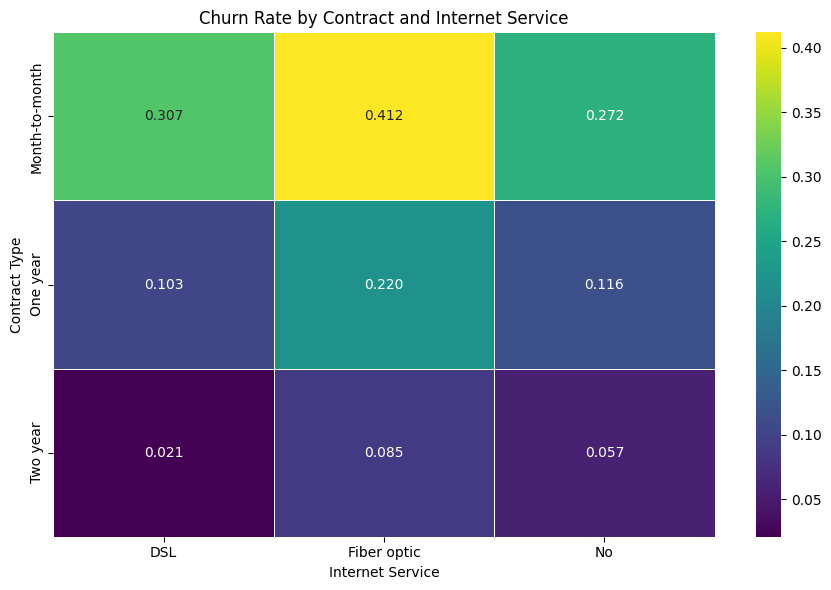

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(churn_risk_table, annot=True, fmt='.3f', cmap='viridis', ax=ax, linewidths=.5)
ax.set_title('Churn Rate by Contract and Internet Service')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Contract Type')
plt.tight_layout()
plt.show()

### Capstone extension challenge 2: New feature `tickets_per_year`

Let's visualize the correlation between `tickets_per_year` and `churn_flag` using a scatter plot.

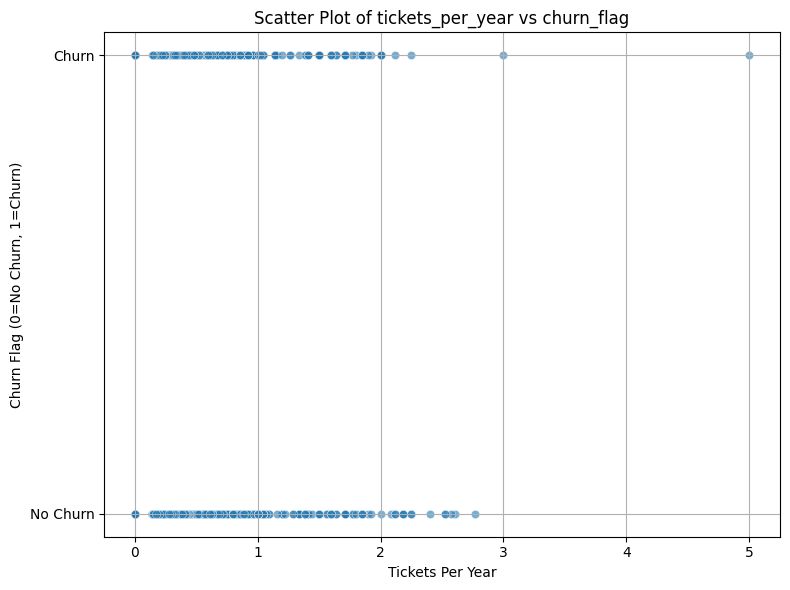

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'tickets_per_year' is available in 'feat' before plotting
feat['tickets_per_year'] = feat['n_tickets'] / (feat['tenure_months']/12 + 1)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='tickets_per_year', y='churn_flag', data=feat, alpha=0.6)
plt.title('Scatter Plot of tickets_per_year vs churn_flag')
plt.xlabel('Tickets Per Year')
plt.ylabel('Churn Flag (0=No Churn, 1=Churn)')
plt.yticks([0, 1], ['No Churn', 'Churn'])
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
correlation = feat['tickets_per_year'].corr(feat['churn_flag'])
print(f"Correlation between tickets_per_year and churn_flag: {correlation:.3f}")

Correlation between tickets_per_year and churn_flag: 0.187


---
### ✅ Capstone complete
You took **three raw telecom files** through the full Day 1–4 workflow — lifecycle framing, multi-source integration, cleaning, statistical EDA, feature engineering, leak-free preprocessing — and finished with a baseline churn model and actionable recommendations. That is the data-to-value pipeline every ML project rests on.